In [60]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [61]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)


In [62]:
from zipfile import ZipFile
dataset = '/content/sentiment140.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("the dataset extracted")

the dataset extracted


In [63]:
import pandas as pd

data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',encoding = 'ISO-8859-1')

In [64]:
data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [65]:
column_names =  ['target','id','date','flag','user','text']
data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names = column_names, encoding = 'ISO-8859-1')


In [66]:
data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [67]:
data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [68]:
data['target'].value_counts()

,count
target,
0,800000
4,800000


In [69]:
data.replace({'target' : {4:1}},inplace = True)

In [70]:
data['target'].value_counts()

,count
target,
0,800000
1,800000


In [71]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'http\S+|@\S+|[^A-Za-z\s]', '', text)
    text = text.lower()
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

data['Cleaned_Tweet'] = data['text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [72]:
data.head()

,target,id,date,flag,user,text,Cleaned_Tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats bummer shoulda got david carr third...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see


In [73]:
import pandas as pd

# Sample list of keywords
keywords = [
    "women safety", "harassment", "gender violence", "domestic abuse",
    "sexual harassment", "catcalling", "women rights", "assault",
    "molestation", "stalking", "gender equality", "safe spaces"
]

# Function to filter tweets containing keywords
def filter_tweets(tweet):
    return any(keyword in tweet for keyword in keywords)

# Filter tweets
filtered_tweets = data[data['Cleaned_Tweet'].apply(filter_tweets)]

# Display filtered results
print(filtered_tweets.head())

       target          id                          date      flag  \
9803        0  1548884114  Fri Apr 17 22:16:57 PDT 2009  NO_QUERY   
23775       0  1557811708  Sun Apr 19 06:06:38 PDT 2009  NO_QUERY   
24834       0  1558134142  Sun Apr 19 07:23:00 PDT 2009  NO_QUERY   
26553       0  1558791350  Sun Apr 19 09:24:45 PDT 2009  NO_QUERY   
28006       0  1559476725  Sun Apr 19 11:14:33 PDT 2009  NO_QUERY   

                  user                                               text  \
9803         vuhhnessa  @OhhMegg no wonder  &amp; PLUS did you know th...   
23775           hilske  @Neessahh Nothing much just stalking celebs. n...   
24834  blackmediascoop  Scoop: poor little Dawne Wilson.  The 36 yr ol...   
26553    MatthewGlitch           oh god im stalking 12 people, poor them    
28006   AnoukAgterberg  bookreport is stalking me  the subject dutch m...   

                                           Cleaned_Tweet  
9803   wonder amp plus know sterling sing ive stalkin...  
2377

In [74]:
print(len(filtered_tweets))

326


In [75]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [76]:
def get_sentiment(text):
    score = sia.polarity_scores(text)

    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

data['Sentiment'] = data['Cleaned_Tweet'].apply(get_sentiment)

In [77]:
data.head()

,target,id,date,flag,user,text,Cleaned_Tweet,Sentiment
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats bummer shoulda got david carr third...,negative
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...,negative
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound,positive
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole body feel itchy like fire,negative
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see,negative


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report


In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

# Vectorize the text data
vectorizer = TfidfVectorizer(max_features=2000)  # Limit to 2000 features
X = vectorizer.fit_transform(data['Cleaned_Tweet'])  # Fit and transform tweets
y = data['Sentiment']  # Target labels

# Save the fitted vectorizer
with open('vectorizer.sav', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [80]:
print(X)
print(y)

  (0, 124)	0.3898188129575457
  (0, 1720)	0.2883193909244924
  (0, 242)	0.4648858734626714
  (0, 735)	0.2494808617972633
  (0, 428)	0.43670973959008874
  (0, 1728)	0.49741660725787257
  (0, 429)	0.2200340162435524
  (1, 1840)	0.32010315220522506
  (1, 275)	0.1846657840976483
  (1, 1834)	0.2811440978803542
  (1, 582)	0.3018217233593526
  (1, 1713)	0.37732188402875827
  (1, 1108)	0.2657782419759456
  (1, 401)	0.28026144684749804
  (1, 1414)	0.34372541456484323
  (1, 1467)	0.23451764175445103
  (1, 1755)	0.18246594022726823
  (1, 51)	0.26283404366536295
  (1, 186)	0.35526971196412593
  (2, 1071)	0.35562040833941444
  (2, 1748)	0.2431426864141912
  (2, 134)	0.4431458689242725
  (2, 1070)	0.4796353355918305
  (2, 1457)	0.43163169162409915
  (2, 1412)	0.3843046064081905
  :	:
  (1599994, 1865)	0.3452752182477867
  (1599994, 1937)	0.4049612946991424
  (1599994, 1979)	0.3002752382605742
  (1599994, 529)	0.3546180041336298
  (1599994, 170)	0.2962703485505128
  (1599994, 932)	0.3269008599138402


In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model (faster than SVM)
model = LogisticRegression(max_iter=1000, solver='saga')  # 'saga' is faster for large data
model.fit(X_train, y_train)



LogisticRegression(max_iter=1000, solver='saga')

In [82]:
# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.88      0.79      0.83     77355
     neutral       0.87      0.95      0.91     89699
    positive       0.92      0.92      0.92    152946

    accuracy                           0.90    320000
   macro avg       0.89      0.89      0.89    320000
weighted avg       0.90      0.90      0.90    320000



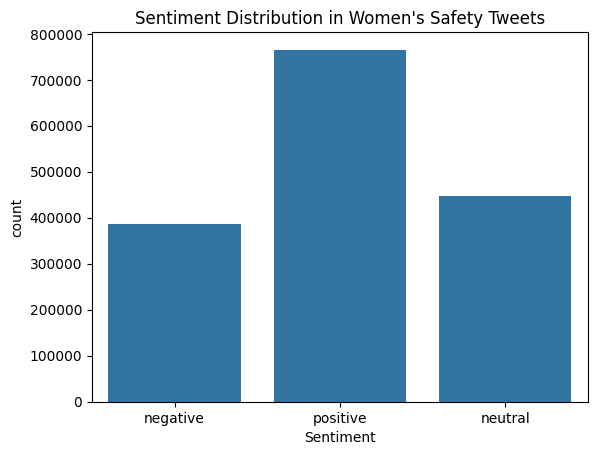

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Sentiment', data=data)
plt.title("Sentiment Distribution in Women's Safety Tweets")
plt.show()

In [84]:
from sklearn.metrics import accuracy_score

X_train_prediction = model.predict(X_train)
print(X_train_prediction)
print(y_train)
training_data_accuracy = accuracy_score(y_train,X_train_prediction)

['positive' 'neutral' 'positive' ... 'neutral' 'negative' 'negative']
1374558    positive
1389115     neutral
1137831    positive
790714     negative
1117911    positive
             ...   
259178     negative
1414414    positive
131932      neutral
671155     negative
121958     negative
Name: Sentiment, Length: 1280000, dtype: object


In [85]:
print('accuracy score on training data =',training_data_accuracy)

accuracy score on training data = 0.899415625


In [86]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(y_test,X_test_prediction)

In [87]:
print('accuracy score on test data =',test_data_accuracy)

accuracy score on test data = 0.89889375


In [88]:
import pickle

filename='trained_model.sav'
pickle.dump(model,open(filename,'wb'))

In [89]:
loaded_model=pickle.load(open('/content/trained_model.sav','rb'))

In [90]:
X_new = X_train[0]
print(X)

  (0, 124)	0.3898188129575457
  (0, 1720)	0.2883193909244924
  (0, 242)	0.4648858734626714
  (0, 735)	0.2494808617972633
  (0, 428)	0.43670973959008874
  (0, 1728)	0.49741660725787257
  (0, 429)	0.2200340162435524
  (1, 1840)	0.32010315220522506
  (1, 275)	0.1846657840976483
  (1, 1834)	0.2811440978803542
  (1, 582)	0.3018217233593526
  (1, 1713)	0.37732188402875827
  (1, 1108)	0.2657782419759456
  (1, 401)	0.28026144684749804
  (1, 1414)	0.34372541456484323
  (1, 1467)	0.23451764175445103
  (1, 1755)	0.18246594022726823
  (1, 51)	0.26283404366536295
  (1, 186)	0.35526971196412593
  (2, 1071)	0.35562040833941444
  (2, 1748)	0.2431426864141912
  (2, 134)	0.4431458689242725
  (2, 1070)	0.4796353355918305
  (2, 1457)	0.43163169162409915
  (2, 1412)	0.3843046064081905
  :	:
  (1599994, 1865)	0.3452752182477867
  (1599994, 1937)	0.4049612946991424
  (1599994, 1979)	0.3002752382605742
  (1599994, 529)	0.3546180041336298
  (1599994, 170)	0.2962703485505128
  (1599994, 932)	0.3269008599138402


In [91]:
prediction = loaded_model.predict(X_new)
print(prediction)

['positive']


In [92]:
nc = 'women are beautiful'
# Transform the new text using the same vectorize

nc_vectorized = vectorizer.transform([nc])

# Now predict using the transformed data
predi = loaded_model.predict(nc_vectorized)
print(predi[0])

positive


In [94]:


# Save fitted vectorizer
pickle.dump(vectorizer, open('vectorizer1.sav', 'wb'))